# Ejercicio 1(c) - Patrones de Demanda Espacio-Temporales en NYC

## Introducción
El objetivo de este ejercicio es analizar cómo varía la demanda de taxis en Nueva York según la zona de la ciudad y el momento del día. Para ello, se combinan dos enfoques complementarios: una clasificación local de la demanda por zona y un agrupamiento de barrios con comportamientos temporales similares.

La lógica general del análisis parte de una idea sencilla pero importante: no todas las zonas de la ciudad tienen el mismo volumen de actividad, por lo que comparar valores absolutos de demanda puede conducir a interpretaciones sesgadas. Por este motivo, se trabaja con medidas relativas dentro de cada barrio y, posteriormente, con perfiles temporales estandarizados para identificar patrones comparables.

In [1]:
import math
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Carga de Datos (Data Mart)
En primer lugar, se carga el dataset agregado ex1c_demand_patterns, que ya contiene la media histórica de viajes por zona, si el día es laborable o fin de semana, y el bloque horario de 3 horas. Este archivo se cruza además con el catálogo taxi_zone_lookup.csv para incorporar la información geográfica de Borough y Zone, lo que mejora la interpretación de los resultados.

El dataset final contiene 4208 filas, lo que refleja la combinación de zonas, franjas horarias y tipo de día utilizada para el análisis. A partir de esta base, se construyen dos variables de apoyo: hour_range, que transforma los bloques horarios en etiquetas legibles como 00-03 o 21-24, y time_context, que distingue entre días laborables (W) y fines de semana (Wend).

In [2]:
ruta_datos = "../data/aggregated/ex1c/ex1c_demand_patterns" 
df = pd.read_parquet(ruta_datos)

# Cargar el catálogo de zonas
ruta_zonas = "../data/external/taxi_zone_lookup.csv"
df_zonas = pd.read_csv(ruta_zonas)

df = df.merge(
    df_zonas[['LocationID', 'Borough', 'Zone']], 
    left_on='pu_location_id', 
    right_on='LocationID', 
    how='left'
).drop(columns=['LocationID'])

print(f"Dataset cargado: {df.shape[0]} filas.")
display(df.head())

Dataset cargado: 4208 filas.


,pu_location_id,is_weekend,hour_block_3h,avg_trips,demand_level,Borough,Zone
0,1,1,0,0.016077,Baja,EWR,Newark Airport
1,1,0,0,0.018852,Baja,EWR,Newark Airport
2,1,0,7,0.036847,Baja,EWR,Newark Airport
3,1,0,1,0.053985,Baja,EWR,Newark Airport
4,1,1,7,0.055734,Baja,EWR,Newark Airport


In [3]:
# Mapear bloques horarios a etiquetas legibles
def map_hour_block(block):
    labels = {
        0: "00-03",
        1: "03-06",
        2: "06-09",
        3: "09-12",
        4: "12-15",
        5: "15-18",
        6: "18-21",
        7: "21-24",
    }
    return labels.get(block, "unknown")

df["hour_range"] = df["hour_block_3h"].map(map_hour_block)

# Crear contexto temporal interpretable
df["time_context"] = np.where(
    df["is_weekend"] == 1,
    "Wend " + df["hour_range"],
    "W " + df["hour_range"]
)

# Etiqueta legible del tipo de día (se usa en varios gráficos)
df['Tipo_Dia'] = df['is_weekend'].map({0: 'Laborable', 1: 'Fin de Semana'})

display(df[["hour_block_3h", "hour_range", "time_context"]].drop_duplicates().head())

,hour_block_3h,hour_range,time_context
0,0,00-03,Wend 00-03
1,0,00-03,W 00-03
2,7,21-24,W 21-24
3,1,03-06,W 03-06
4,7,21-24,Wend 21-24


## Clasificación de Demanda Local

La primera parte metodológica consiste en clasificar la demanda de cada zona en tres niveles: Baja, Media y Alta. Esta clasificación no se realiza con umbrales globales, sino mediante terciles locales calculados dentro de cada zona, de modo que cada barrio se evalúa respecto a su propio comportamiento histórico.

Este criterio es especialmente útil porque permite comparar correctamente zonas con naturalezas muy distintas. No es razonable interpretar Midtown Manhattan y una zona residencial periférica con la misma escala absoluta, ya que sus volúmenes de movilidad responden a dinámicas urbanas diferentes. La clasificación relativa permite, por tanto, detectar qué horas son pico o valle dentro de cada contexto local, y no solo en el conjunto de la ciudad.

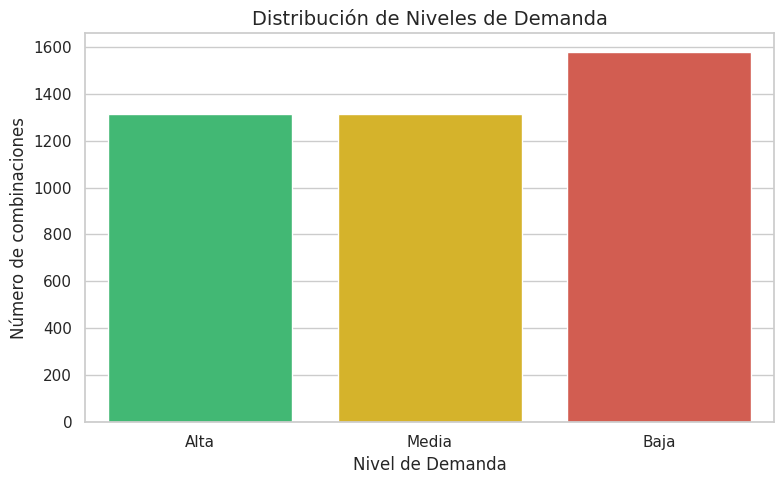

In [4]:
# Contar cuántas franjas horarias/zonas caen en cada categoría
conteo_demanda = df['demand_level'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=conteo_demanda.index,
    y=conteo_demanda.values,
    order=["Alta", "Media", "Baja"],
    hue=conteo_demanda.index,
    palette=["#e74c3c", "#f1c40f", "#2ecc71"],
    legend=False
)

plt.title("Distribución de Niveles de Demanda", fontsize=14)
plt.ylabel("Número de combinaciones")
plt.xlabel("Nivel de Demanda")
plt.tight_layout()
plt.show()

La distribución de niveles de demanda resulta equilibrada, lo cual es coherente con el uso de terciles. Esto confirma que el procedimiento reparte de forma homogénea las observaciones entre las tres categorías, evitando que una sola etiqueta domine el análisis por efecto del volumen agregado.

### Análisis Temporal de la Demanda
Esta sección explora cómo evoluciona la demanda a lo largo del día, tanto a nivel global como diferenciado por borough. Se utilizan tres visualizaciones complementarias: una serie temporal agregada con banda de variabilidad, un heatmap zona-hora para los días laborables y no laborables, y pequeños múltiplos por borough.

### Serie Temporal Agregada con Banda de Variación

El siguiente gráfico muestra la evolución media de la demanda a lo largo del día, separada entre días laborables y fines de semana, acompañada de una banda que recoge el rango entre el percentil 10 y el percentil 90 de la distribución de viajes entre zonas. Esta representación es más informativa que una simple media porque captura la heterogeneidad entre barrios: la amplitud de la banda refleja cuánto varía el comportamiento de las distintas zonas en cada franja horaria.

En días laborables se aprecia un perfil con mínimo en las primeras horas de la mañana y crecimiento sostenido hacia la tarde-noche, coherente con los desplazamientos relacionados con el trabajo y el ocio. En fines de semana, el patrón se suaviza y los picos se desplazan ligeramente hacia franjas más tardías, lo que refleja un uso más relacionado con el ocio y una actividad más dispersa a lo largo del día.

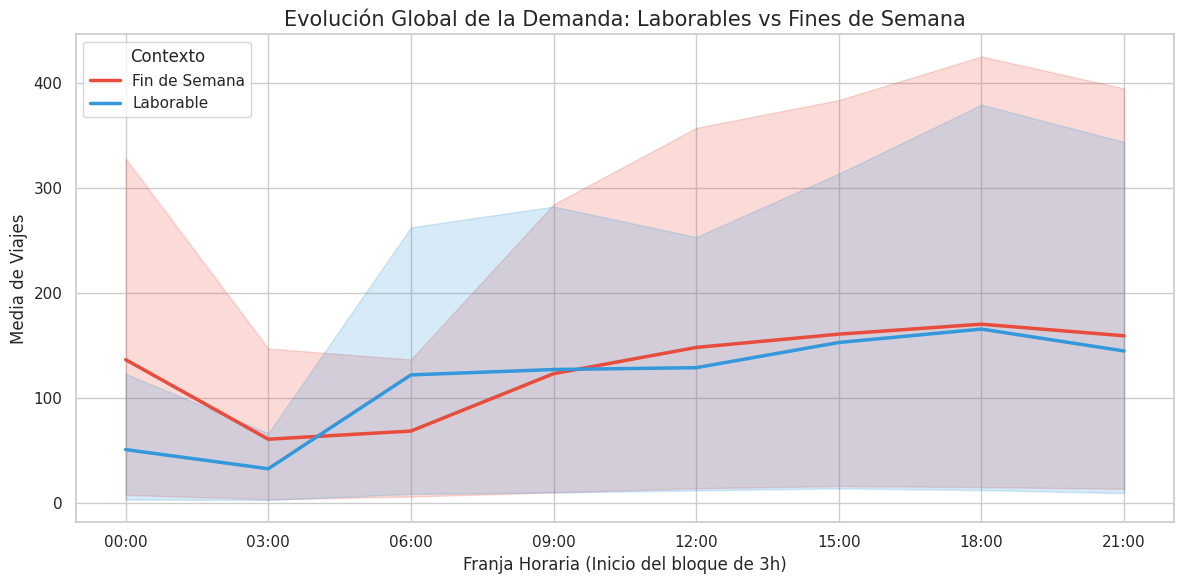

In [5]:
    # Agregación: media + percentiles
agg = df.groupby(['hour_block_3h', 'Tipo_Dia'])['avg_trips'].agg(
    mean='mean',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90)
).reset_index()

palette = {'Laborable': '#3498db', 'Fin de Semana': '#e74c3c'}

for tipo in agg['Tipo_Dia'].unique():
    subset = agg[agg['Tipo_Dia'] == tipo]
    
    # Línea de media
    plt.plot(subset['hour_block_3h'], subset['mean'], 
             label=tipo, color=palette[tipo], linewidth=2.5)
    
    # Banda percentiles
    plt.fill_between(subset['hour_block_3h'], 
                     subset['p10'], subset['p90'], 
                     color=palette[tipo], alpha=0.2)

plt.title("Evolución Global de la Demanda: Laborables vs Fines de Semana", fontsize=15)
plt.xlabel("Franja Horaria (Inicio del bloque de 3h)", fontsize=12)
plt.ylabel("Media de Viajes", fontsize=12)

plt.xticks(range(8), ['00:00', '03:00', '06:00', '09:00', 
                      '12:00', '15:00', '18:00', '21:00'])

plt.legend(title="Contexto")
plt.tight_layout()
plt.show()

### Heatmap de Demanda por Zona y Franja Horaria

Los mapas de calor siguientes muestran la demanda media por franja horaria para las 20 zonas con mayor volumen total de viajes, separados entre días laborables y no laborables. Esta representación permite identificar de un vistazo los picos de actividad propios de cada zona y detectar si su comportamiento cambia según el tipo de día.

En días laborables, los aeropuertos (JFK, LaGuardia) y las zonas céntricas de Manhattan concentran la actividad en franjas diurnas y vespertinas, mientras que en fines de semana los patrones se vuelven más dispersos. Zonas como East Village o Lower East Side exhiben un desplazamiento notable de la actividad hacia franjas más tardías durante el fin de semana, lo que es coherente con su carácter de ocio nocturno.

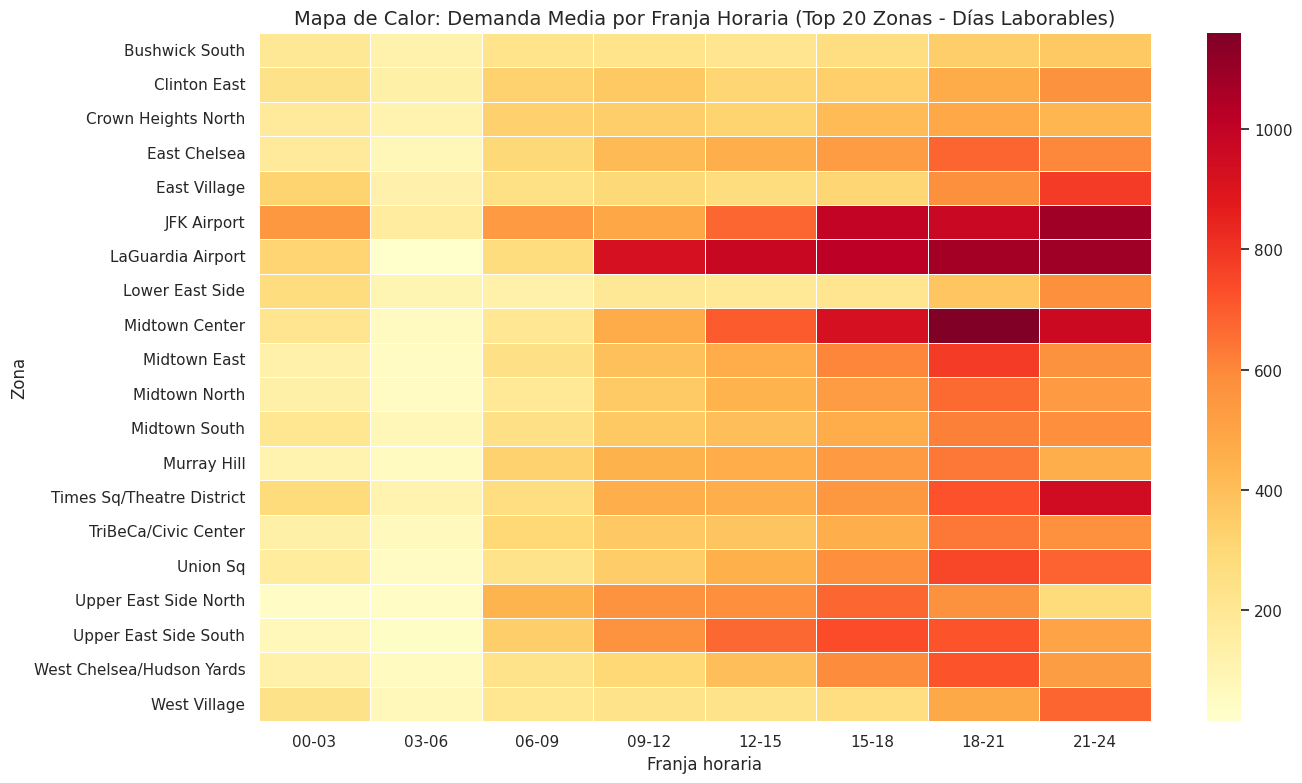

In [6]:
# 1. Identificar las 20 zonas con más viajes en promedio
top_zonas = df.groupby('Zone')['avg_trips'].sum().nlargest(20).index

# --- Heatmap: Días Laborables ---
df_top = df[(df['Zone'].isin(top_zonas)) & (df['is_weekend'] == False)]
pivot_demanda = df_top.pivot(index='Zone', columns='hour_range', values='avg_trips')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_demanda, cmap="YlOrRd", annot=False, linewidths=.5)
plt.title("Mapa de Calor: Demanda Media por Franja Horaria (Top 20 Zonas - Días Laborables)", fontsize=14)
plt.ylabel("Zona")
plt.xlabel("Franja horaria")
plt.tight_layout()
plt.show()

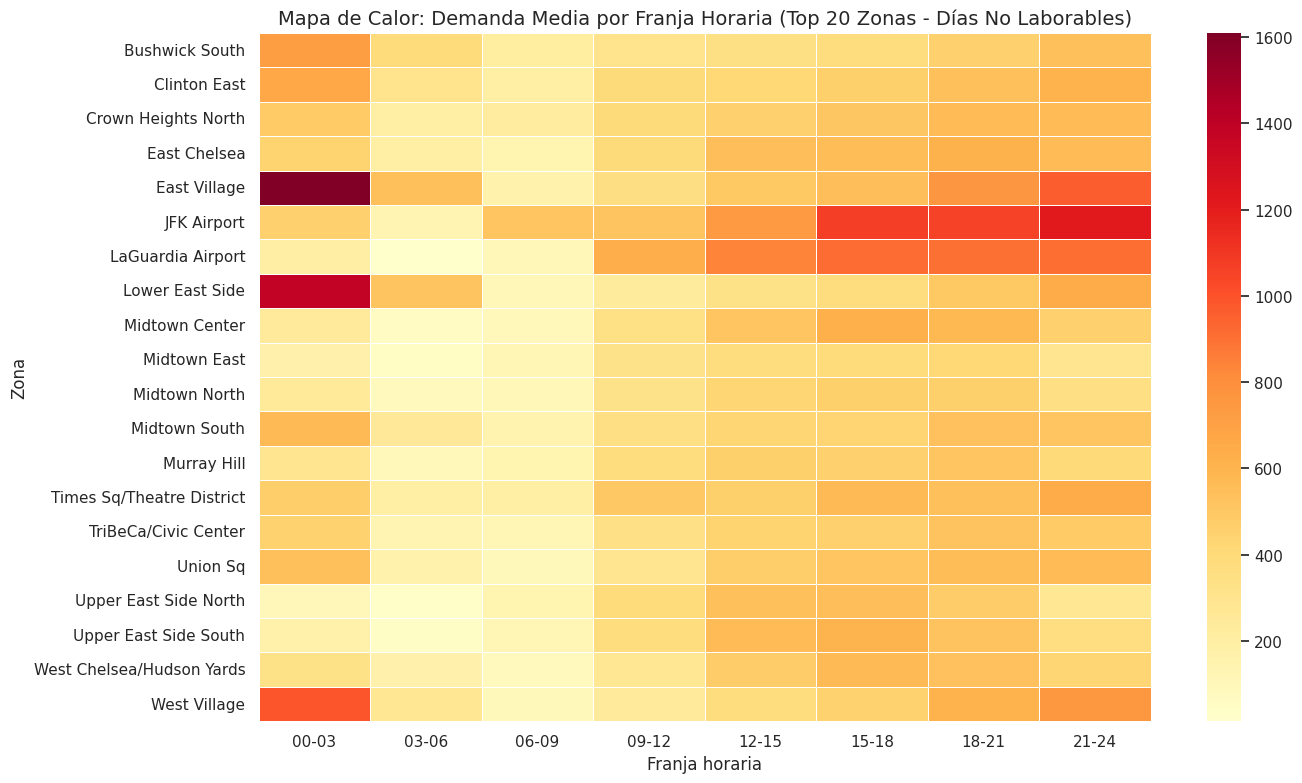

In [7]:
# --- Heatmap: Días No Laborables ---
df_top = df[(df['Zone'].isin(top_zonas)) & (df['is_weekend'] == True)]
pivot_demanda = df_top.pivot(index='Zone', columns='hour_range', values='avg_trips')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_demanda, cmap="YlOrRd", annot=False, linewidths=.5)
plt.title("Mapa de Calor: Demanda Media por Franja Horaria (Top 20 Zonas - Días No Laborables)", fontsize=14)
plt.ylabel("Zona")
plt.xlabel("Franja horaria")
plt.tight_layout()
plt.show()

### Patrón de Demanda Medio a lo Largo del Día

El siguiente gráfico de línea muestra la evolución media de la demanda agregando todas las zonas y tipos de día. Aunque este nivel de agregación suaviza diferencias entre barrios, permite observar claramente el mínimo estructural en la franja 03:00–06:00 y la tendencia ascendente que culmina en torno a las 18:00–21:00. Esta curva proporciona una referencia global útil para comparar con perfiles específicos por zona o clúster.

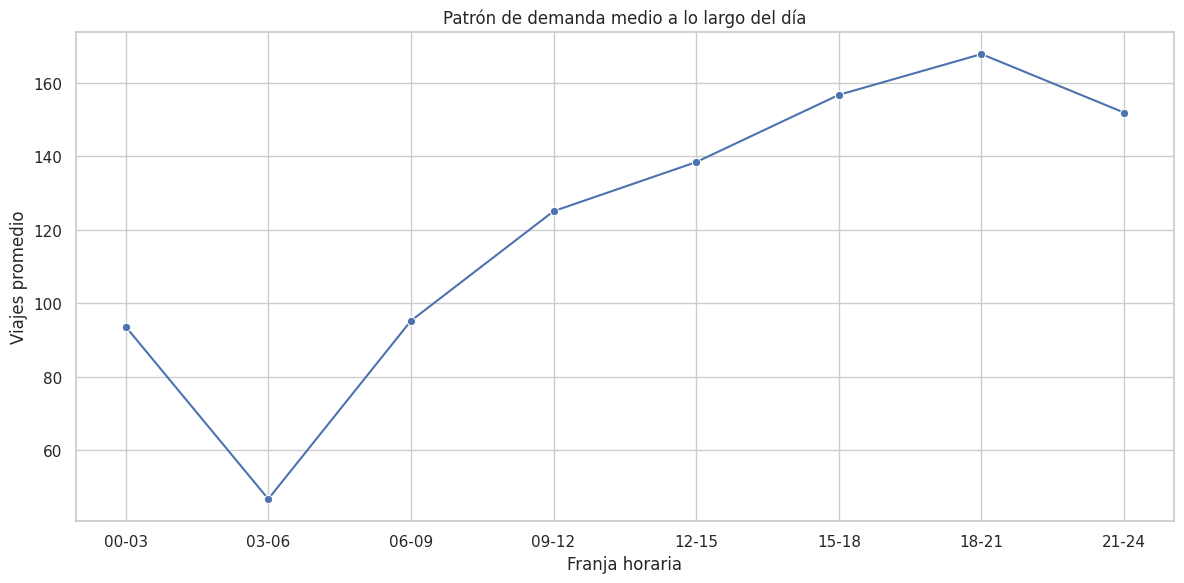

In [8]:
df_time = df.groupby("hour_range")["avg_trips"].mean().reset_index()

plt.figure()
sns.lineplot(data=df_time, x="hour_range", y="avg_trips", marker="o")

plt.title("Patrón de demanda medio a lo largo del día")
plt.xlabel("Franja horaria")
plt.ylabel("Viajes promedio")
plt.tight_layout()
plt.show()

### Small Multiples por Borough

La siguiente visualización descompone el patrón de demanda por borough, comparando en cada subgráfico el perfil de días laborables frente al de fines de semana. Al utilizar escalas Y independientes, se evita que los volúmenes muy distintos entre boroughs (Manhattan vs. Staten Island, por ejemplo) dificulten la lectura de las formas de cada curva.

Los resultados confirman que cada borough tiene una dinámica propia. Manhattan muestra los perfiles más pronunciados y con mayor diferencia entre laborables y fines de semana. Queens presenta un patrón influenciado de forma notable por los aeropuertos, con actividad relevante incluso en franjas nocturnas. Brooklyn y el Bronx exhiben curvas más suaves y similares entre ambos tipos de día, coherentes con una demanda de carácter más residencial. EWR (Newark Airport), con volúmenes muy bajos en la escala general, muestra no obstante una estructura horaria claramente diferenciada.

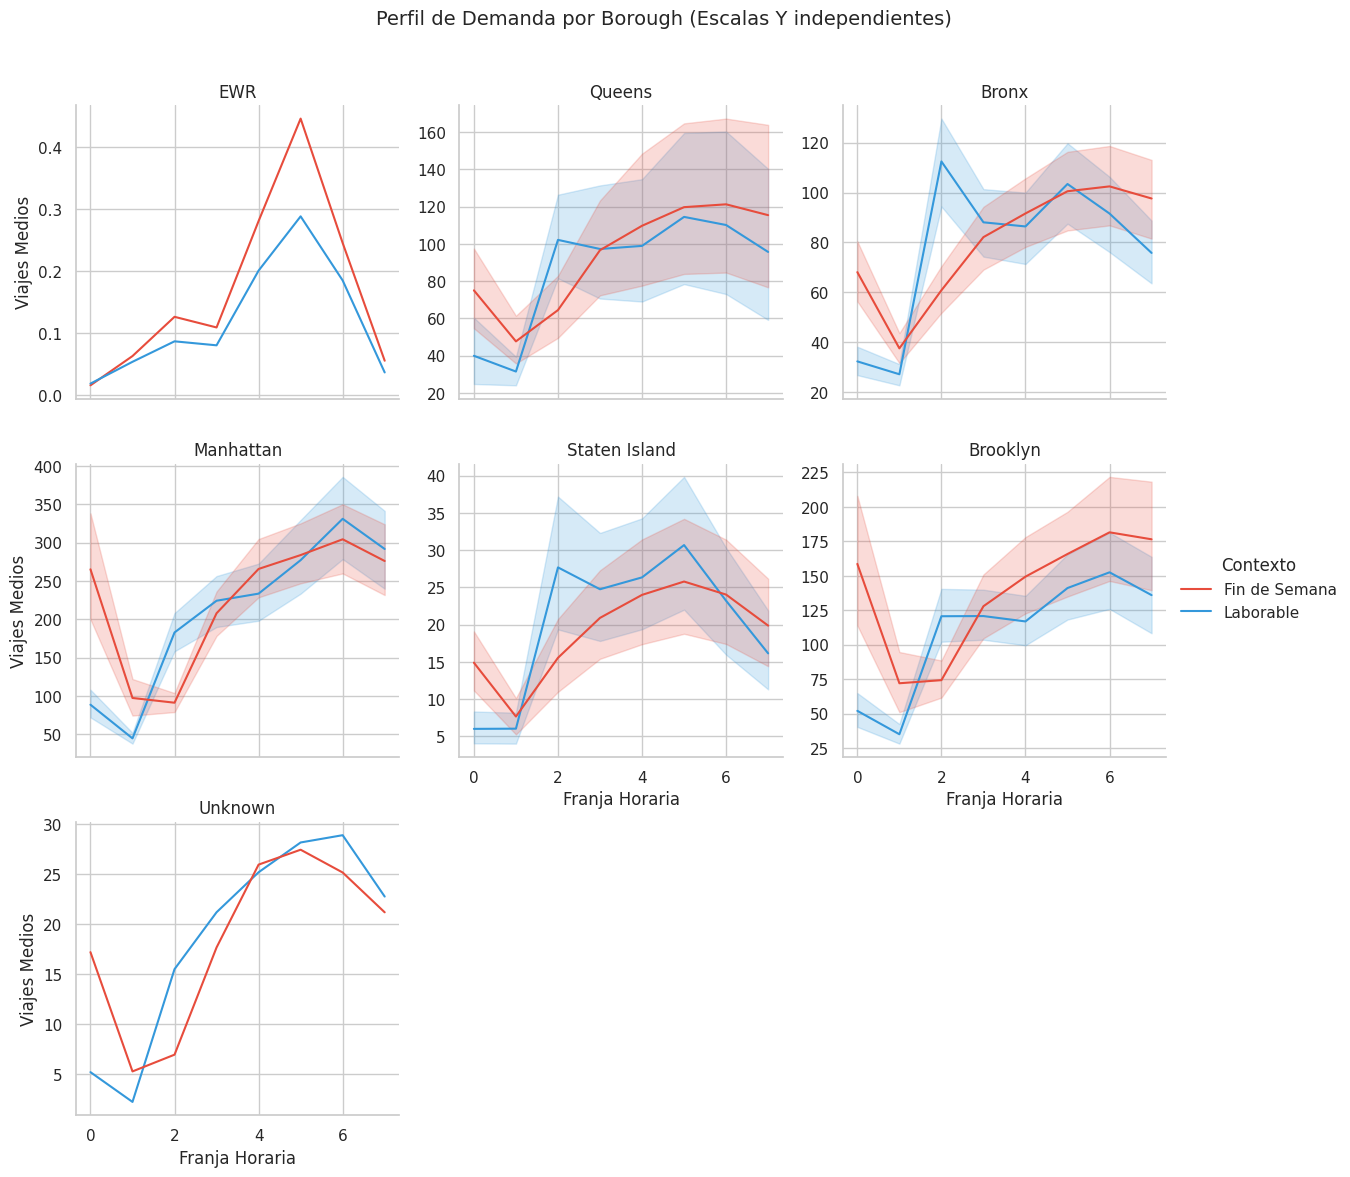

In [9]:
# Small multiples por borough: laborable vs fin de semana
g = sns.FacetGrid(df.dropna(subset=['Borough']), col="Borough", col_wrap=3, height=4,
                  sharey=False)
g.map_dataframe(sns.lineplot, x="hour_block_3h", y="avg_trips", hue="Tipo_Dia",
                palette=palette, errorbar=('ci', 95))
 
g.set_axis_labels("Franja Horaria", "Viajes Medios")
g.set_titles(col_template="{col_name}")
g.add_legend(title="Contexto")
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Perfil de Demanda por Borough (Escalas Y independientes)", fontsize=14)
plt.show()

### Matriz de Transición Laborable → Fin de Semana

La matriz de transición recoge el incremento porcentual de la demanda media en fin de semana respecto a los días laborables, desglosado por borough y franja horaria. Los valores positivos (tonos cálidos) indican franjas donde la actividad se intensifica en fin de semana; los valores negativos (tonos fríos) señalan franjas donde la demanda cae.

El patrón más llamativo es el fuerte incremento en las primeras horas de la madrugada (00:00–06:00) en casi todos los boroughs, especialmente en Brooklyn, Manhattan y el Bronx. Esto refleja la mayor actividad nocturna del fin de semana. Por el contrario, las franjas de mañana y mediodía tienden a mostrar caídas, coherentes con la ausencia de desplazamientos al trabajo. EWR presenta un comportamiento opuesto al resto, con incrementos diurnos, probablemente por la mayor frecuencia de vuelos de ocio en fin de semana.

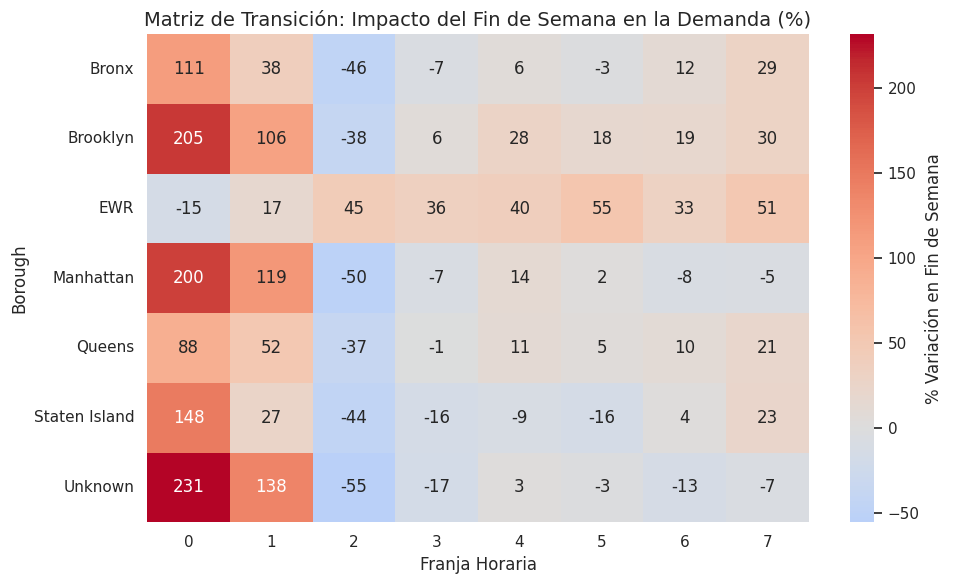

In [10]:
# Pivotamos para tener Borough en filas y Franja en columnas (diferencia Finde - Diario)
df_diario = df[df['is_weekend'] == False].pivot_table(
    index='Borough', columns='hour_block_3h', values='avg_trips')
df_finde  = df[df['is_weekend'] == True].pivot_table(
    index='Borough', columns='hour_block_3h', values='avg_trips')
 
# Calculamos el incremento porcentual del Finde respecto al Diario
matriz_transicion = ((df_finde - df_diario) / df_diario * 100).fillna(0)
 
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_transicion, cmap="coolwarm", center=0, annot=True, fmt=".0f",
            cbar_kws={'label': '% Variación en Fin de Semana'})
plt.title("Matriz de Transición: Impacto del Fin de Semana en la Demanda (%)", fontsize=14)
plt.xlabel("Franja Horaria")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

## Agrupación de zonas con K-Means

La segunda parte del ejercicio consiste en agrupar zonas según su patrón temporal de demanda mediante `K-Means`. Para ello, los datos se reorganizan en una matriz donde cada fila representa una zona y cada columna un contexto temporal concreto, diferenciando entre día laborable y fin de semana.

Antes de aplicar el algoritmo, se utiliza `StandardScaler` para estandarizar las variables. Este paso es fundamental, porque evita que el agrupamiento dependa únicamente del volumen absoluto de viajes y favorece que el modelo capture la forma del patrón temporal. En otras palabras, el objetivo no es solo separar zonas con mucha o poca demanda, sino detectar zonas que “se comportan parecido” a lo largo del tiempo.

El modelo se ejecuta con cuatro clústeres, lo que permite obtener perfiles relativamente diferenciados de comportamiento urbano. La distribución de zonas por clúster es desigual, con grupos de distinto tamaño, lo cual es normal en un problema de movilidad urbana, donde no todos los patrones tienen la misma frecuencia.

In [11]:
# Pivotamos: Filas = Zonas, Columnas = Contextos temporales, Valores = Viajes medios
df_pivot = df.pivot_table(
    index=['pu_location_id', 'Borough', 'Zone'],
    columns='time_context',
    values='avg_trips',
    fill_value=0 # Si una zona no tiene viajes en una franja, ponemos 0
).reset_index()

# Limpiamos los nombres de las columnas tras el pivot
df_pivot.columns.name = None

display(df_pivot.head())

,pu_location_id,Borough,Zone,W 00-03,W 03-06,W 06-09,W 09-12,W 12-15,W 15-18,W 18-21,W 21-24,Wend 00-03,Wend 03-06,Wend 06-09,Wend 09-12,Wend 12-15,Wend 15-18,Wend 18-21,Wend 21-24
0,1,EWR,Newark Airport,0.018852,0.053985,0.086975,0.080548,0.200943,0.288346,0.185090,0.036847,0.016077,0.063237,0.126474,0.109325,0.280815,0.445874,0.245445,0.055734
1,2,Queens,Jamaica Bay,0.013282,0.005998,0.022279,0.056127,0.094259,0.129820,0.097258,0.037704,0.030011,0.011790,0.039657,0.120043,0.271168,0.190782,0.096463,0.037513
2,3,Bronx,Allerton/Pelham Gardens,17.239503,18.324764,94.304199,71.128106,73.546272,83.697087,66.520137,54.150814,35.814577,19.848875,48.080386,67.327974,69.945338,76.419078,71.976420,67.758842
3,4,Manhattan,Alphabet City,53.705227,28.281919,86.721937,92.781063,68.841474,72.538132,104.777635,107.797772,255.633441,88.115756,54.819936,97.438371,111.244373,112.957128,137.555198,148.157556
4,5,Staten Island,Arden Heights,1.751928,2.938303,14.593402,10.770351,9.332048,9.858183,7.257498,4.119966,4.885316,3.138264,7.560557,9.939979,9.994641,9.012862,9.740622,6.330118


In [ ]:
# Seleccionamos solo las columnas numéricas (las franjas horarias)
columnas_features = [col for col in df_pivot.columns if col not in ['pu_location_id', 'Borough', 'Zone']]
X = df_pivot[columnas_features]

# Normalizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

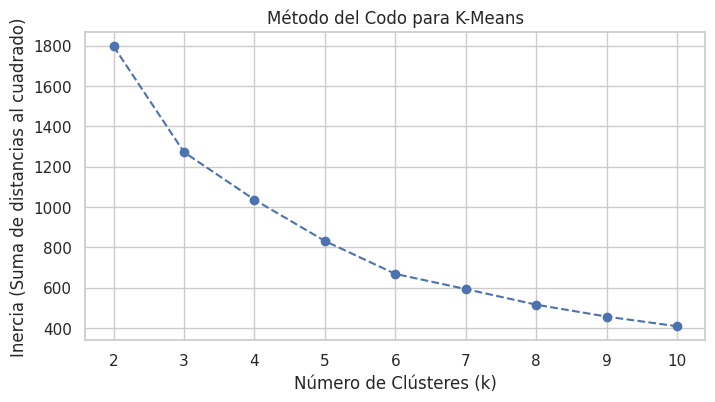

In [27]:
inercia = []
rango_k = range(2, 11)
for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inercia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.xticks(rango_k)
plt.show()

El Método del Codo sugiere 3 clústeres, pero se eligen 4 para lograr una segmentación más detallada y útil, priorizando valor estratégico frente a una ligera pérdida de compacidad.

In [ ]:
# Aplicamos K-Means (vamos a buscar 4 perfiles típicos de barrios)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_pivot['Cluster'] = kmeans.fit_predict(X_scaled)

print("Número de zonas por clúster:")
print(df_pivot['Cluster'].value_counts())

# Unimos el clúster asignado al dataframe largo original
df_clusterizado = df.merge(df_pivot[['pu_location_id', 'Cluster']], on='pu_location_id', how='inner')

Número de zonas por clúster:
Cluster
3    101
0     88
2     50
1     22
Name: count, dtype: int64


### Dispersión Interna de la Demanda por Clúster (Violin Plot)

El violin plot permite evaluar no solo el nivel medio de demanda de cada clúster, sino también su distribución interna. Un clúster con un violín estrecho y simétrico indica un grupo homogéneo, donde todas las zonas tienen un comportamiento parecido. Por el contrario, un violín ancho o con múltiples nodos de densidad revela mayor heterogeneidad interna.

El uso de escala logarítmica en el eje Y es necesario porque la demanda varía en varios órdenes de magnitud entre zonas. El parámetro `split=True` en seaborn superpone en un mismo violín la distribución de días laborables (izquierda) y fines de semana (derecha), lo que facilita comparar ambos contextos para cada clúster.

Los clústeres de mayor volumen (1 y 2) muestran distribuciones más dispersas, con colas superiores pronunciadas que corresponden a las zonas de muy alta demanda, como los aeropuertos o el centro de Manhattan. Los clústeres de menor volumen (0 y 3) presentan distribuciones más compactas, coherentes con un perfil de movilidad más uniforme y de menor intensidad.

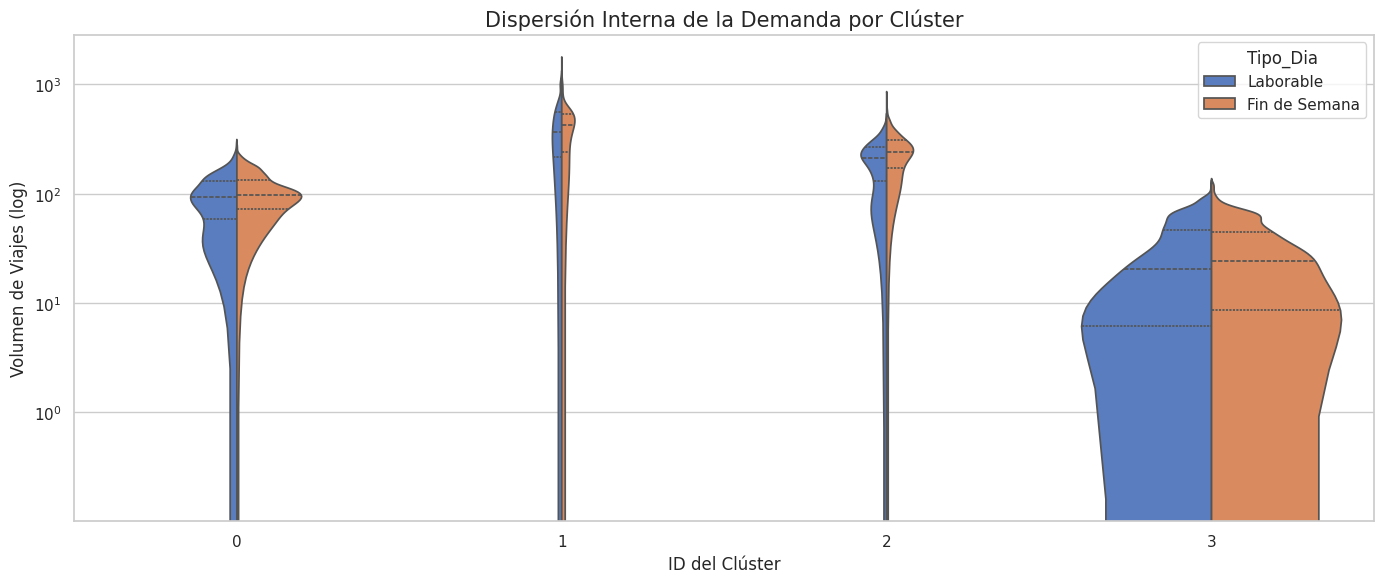

In [13]:
plt.figure(figsize=(14, 6))
# El split=True junta la mitad laborable y la mitad finde en el mismo violín
sns.violinplot(data=df_clusterizado, x='Cluster', y='avg_trips', hue='Tipo_Dia', 
               split=True, inner="quartile", palette="muted")

plt.title("Dispersión Interna de la Demanda por Clúster", fontsize=15)
plt.xlabel("ID del Clúster")
plt.ylabel("Volumen de Viajes (log)")
plt.yscale('log')
plt.tight_layout()
plt.show()

### Perfil de los clústeres
El análisis de los centroides de cada clúster permite interpretar los perfiles resultantes. Aunque el número exacto de zonas por grupo varía, sí se observan diferencias claras en su comportamiento temporal, lo que sugiere que el algoritmo ha capturado estructuras reales dentro de la demanda.

Al revisar ejemplos representativos, aparecen zonas claramente vinculadas a actividad aeroportuaria, como JFK Airport y LaGuardia Airport, que forman parte de uno de los grupos con mayor volumen total. Estas áreas presentan un comportamiento muy distinto al de barrios residenciales o mixtos, porque su demanda está más condicionada por viajes de conexión y flujos no cotidianos.

También se identifican clústeres asociados a zonas densamente urbanas de Manhattan y otras áreas con intensa actividad económica o de ocio, como Midtown Center, Times Sq/Theatre District, East Village o Gramercy. Estas zonas tienden a concentrar demanda elevada y patrones horarios más marcados, especialmente en franjas vinculadas al trabajo, la restauración, el turismo y el ocio nocturno.

Por otro lado, existen clústeres formados por zonas con menor volumen relativo o con una dinámica más equilibrada, como Carroll Gardens, Crotona Park East o Manhattanville. En estos casos, la demanda aparece más repartida en el tiempo, lo que sugiere patrones menos explosivos y posiblemente más relacionados con movilidad local cotidiana.

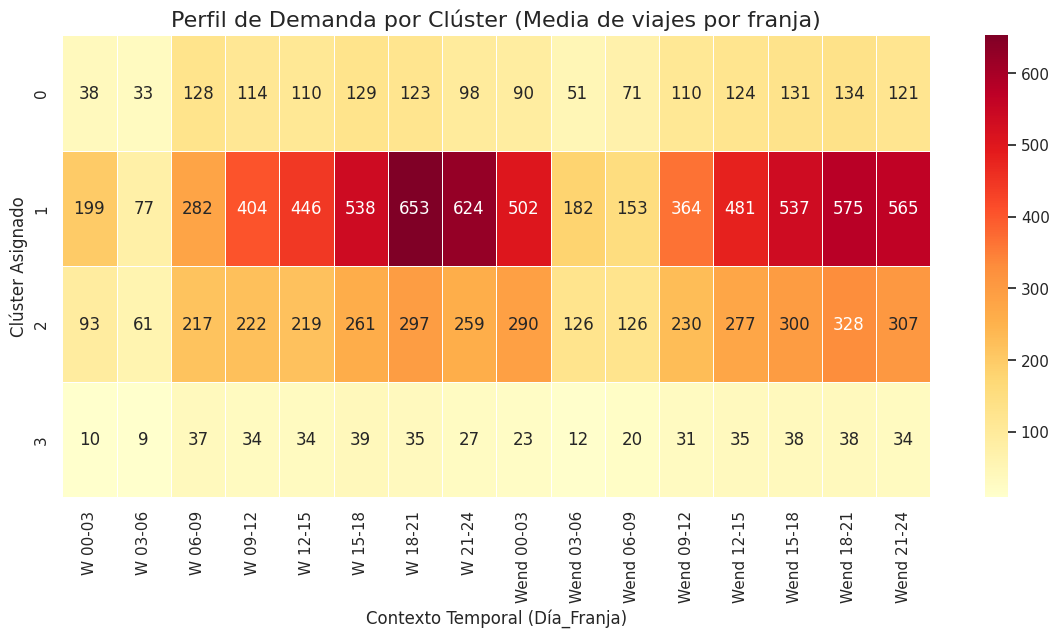

In [14]:
# Ordenamos las columnas lógicamente (Diario mañana -> tarde -> Finde...)
columnas_ordenadas = sorted(columnas_features)

# Calculamos el centroide (la media) de cada clúster en su escala original
cluster_centers = df_pivot.groupby('Cluster')[columnas_ordenadas].mean()

# Dibujamos un heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_centers, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=.5)
plt.title("Perfil de Demanda por Clúster (Media de viajes por franja)", fontsize=16)
plt.xlabel("Contexto Temporal (Día_Franja)")
plt.ylabel("Clúster Asignado")
plt.show()

### Radar Chart de Centroides (Firma Temporal Normalizada)

El gráfico radar complementa el heatmap anterior al representar las "formas" de los perfiles temporales normalizadas entre 0 y 1. Al eliminar las diferencias de escala, permite comparar directamente el ritmo diario de cada clúster independientemente de su volumen absoluto de viajes.

Cada eje del radar corresponde a una franja horaria de días laborables, y la superficie de cada polígono muestra en qué momentos del día se concentra relativamente más actividad. Un polígono con vértices pronunciados en determinadas franjas indica un clúster con picos horarios marcados, mientras que una forma más circular señala una demanda más uniforme a lo largo del día.

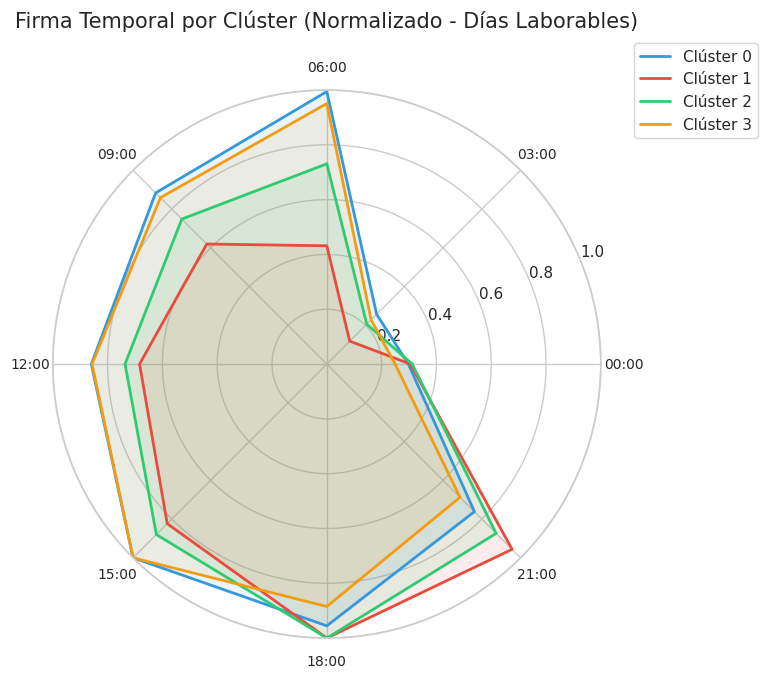

In [15]:
cols_diario = [col for col in df_pivot.columns if col.startswith('W ')]
centroides_radar = df_pivot.groupby('Cluster')[cols_diario].mean()
 
# Normalizamos de 0 a 1 para comparar las "formas" independientemente del volumen
centroides_radar = centroides_radar.div(centroides_radar.max(axis=1), axis=0)
 
# Las 8 franjas horarias de días laborables
categorias = ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00']
N = len(categorias)
 
angulos = [n / float(N) * 2 * math.pi for n in range(N)]
angulos += angulos[:1]  # Cerrar el círculo
 
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
 
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
 
for i, row in centroides_radar.iterrows():
    valores = row.tolist()
    valores += valores[:1]  # Cerrar el círculo
    ax.plot(angulos, valores, linewidth=2, linestyle='solid',
            color=colors[i], label=f'Clúster {i}')
    ax.fill(angulos, valores, color=colors[i], alpha=0.1)
 
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylim(0, 1)
plt.title("Firma Temporal por Clúster (Normalizado - Días Laborables)", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [16]:
# Zonas representativas de cada clúster (top 5 por demanda total)
for cluster_id in sorted(df_pivot['Cluster'].unique()):
    print(f"\n--- CLÚSTER {cluster_id} ---")
    
    zonas_cluster = df_pivot[df_pivot['Cluster'] == cluster_id].copy()
    zonas_cluster['Demanda_Total'] = zonas_cluster[columnas_features].sum(axis=1)
    
    top_5 = zonas_cluster.sort_values('Demanda_Total', ascending=False).head(5)
    
    for _, row in top_5.iterrows():
        print(f"{row['Borough']} - {row['Zone']} ({row['Demanda_Total']:.0f} viajes)")


--- CLÚSTER 0 ---
Manhattan - Yorkville East (2430 viajes)
Manhattan - Washington Heights North (2412 viajes)
Queens - Flushing (2361 viajes)
Brooklyn - Bay Ridge (2308 viajes)
Brooklyn - Downtown Brooklyn/MetroTech (2237 viajes)

--- CLÚSTER 1 ---
Queens - JFK Airport (11184 viajes)
Queens - LaGuardia Airport (10202 viajes)
Manhattan - East Village (8403 viajes)
Manhattan - Midtown Center (7601 viajes)
Manhattan - Times Sq/Theatre District (7403 viajes)

--- CLÚSTER 2 ---
Brooklyn - Williamsburg (North Side) (5152 viajes)
Manhattan - Gramercy (4960 viajes)
Brooklyn - East New York (4753 viajes)
Manhattan - Upper West Side South (4655 viajes)
Queens - Astoria (4581 viajes)

--- CLÚSTER 3 ---
Manhattan - Seaport (1203 viajes)
Brooklyn - Carroll Gardens (1078 viajes)
Manhattan - Manhattanville (1040 viajes)
Bronx - Crotona Park East (981 viajes)
Brooklyn - Madison (969 viajes)


### Distribución Espacial de los Clústeres (Mapa Coroplético)

El mapa de coropletas geolocaliza cada zona de taxi según el clúster que le ha sido asignado, lo que permite identificar si los patrones temporales detectados por K-Means tienen una expresión espacial coherente.

La distribución espacial muestra agrupaciones geográficas claras: las zonas del clúster de mayor volumen (principalmente el 1) se concentran en el centro y sur de Manhattan y en torno a los aeropuertos, mientras que los clústeres de menor intensidad ocupan áreas periféricas de Queens, Brooklyn, el Bronx y Staten Island. Esta coherencia espacial es una validación indirecta del clustering: si zonas próximas comparten el mismo clúster, es señal de que el modelo ha capturado estructuras urbanas reales, no agrupaciones espurias.

Las zonas en gris claro corresponden a áreas sin datos en el dataset.

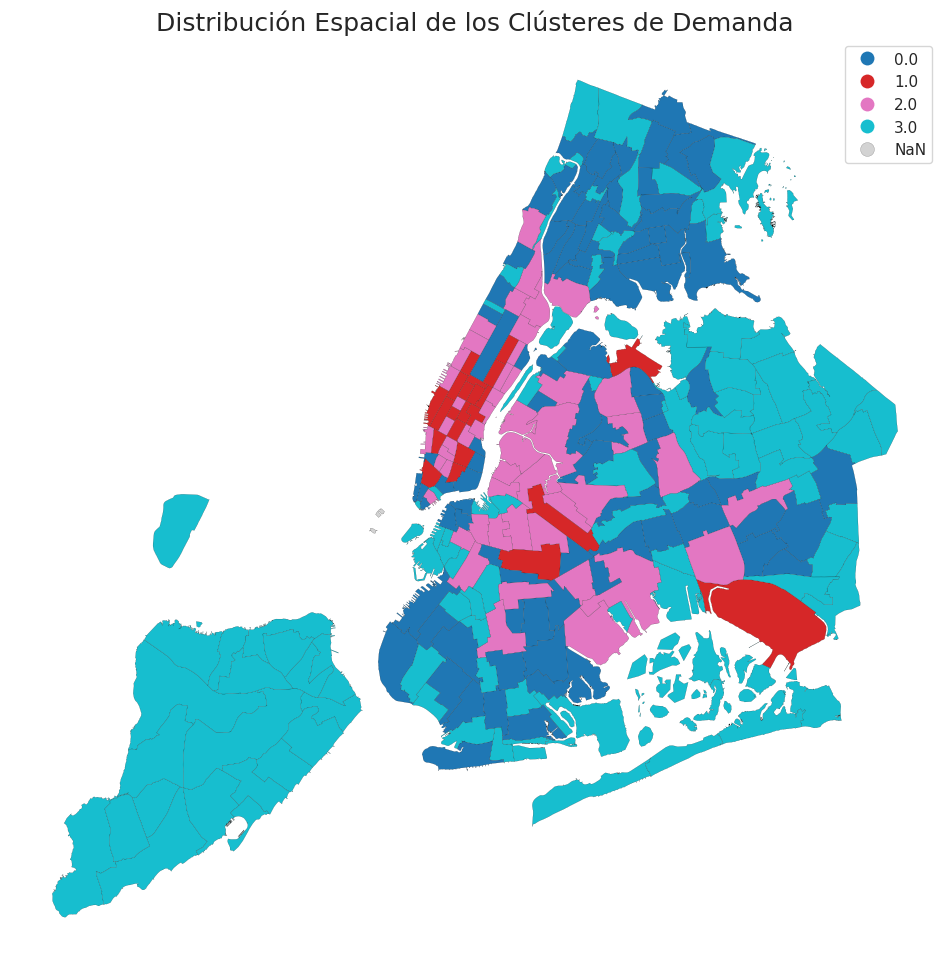

In [17]:
ruta_shp = "../data/external/taxi_zones/taxi_zones.shp" 
gdf_zonas = gpd.read_file(ruta_shp)

# Cruzamos el mapa con nuestros clusters
gdf_mapa = gdf_zonas.merge(df_pivot[['pu_location_id', 'Cluster']], 
                            left_on='LocationID', right_on='pu_location_id', how='left')

# Dibujamos
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
# Para que las zonas sin datos (Na) se vean grises
gdf_mapa.plot(column='Cluster', ax=ax, legend=True, categorical=True, 
                cmap='tab10', missing_kwds={'color': 'lightgrey'}, 
                edgecolor='black', linewidth=0.1)

plt.title("Distribución Espacial de los Clústeres de Demanda", fontsize=18)
ax.set_axis_off()
plt.show()

## Conclusiones
El análisis muestra que la demanda de taxis en Nueva York presenta una estructura claramente heterogénea tanto en el espacio como en el tiempo. Las zonas no se comportan igual, y su demanda depende del tipo de área urbana, del día de la semana y de la franja horaria observada.

La clasificación local por terciles ha resultado especialmente útil porque permite identificar niveles de demanda relativos dentro de cada zona, evitando la distorsión que produciría una comparación basada exclusivamente en magnitudes absolutas. Gracias a ello, se pueden detectar horas pico y horas valle de forma más justa para cada barrio, independientemente de su tamaño o intensidad de uso.

Por su parte, el clustering con K-Means aporta una capa adicional de interpretación al agrupar zonas con curvas temporales similares. Esto permite pasar de una descripción puntual de la demanda a una visión más estructural de la ciudad, en la que se distinguen perfiles ligados a actividad aeroportuaria, urbana central, ocio o movilidad más residencial.

En conjunto, el trabajo confirma que la movilidad en taxi no responde a un patrón único, sino a múltiples lógicas de uso que conviene analizar de forma diferenciada. Desde una perspectiva aplicada, estos resultados pueden servir para optimizar la asignación de vehículos, detectar zonas con infra o sobrecobertura y apoyar decisiones de planificación urbana y logística más ajustadas a la realidad de cada área.